# Lease Analysis Evaluator

This notebook evaluates the AI lease agent's output against the ground truth built in `01_build_ground_truth.ipynb`.

**Inputs:**
- `ground_truth/ground_truth.json` — structured ground truth (run notebook 01 first)
- `../agent/clause_findings.csv` — per-clause agent findings
- `../agent/improvement_decision_report.md` — agent's narrative report

**Outputs:**
- Printed metrics summary + bar chart
- `evaluation_report.md` — full written evaluation report

**Metrics computed:**
| Metric | Method |
|--------|--------|
| Coverage Rate | LLM-based matching |
| Label Accuracy | LLM-based matching |
| Accuracy | LLM-as-judge (GPT-4o) |
| Completeness | LLM-as-judge |
| Severity Calibration | LLM-as-judge |
| Recommendation Quality | LLM-as-judge |
| Overall Score | Weighted average |

## Cell 1: Setup

In [ ]:
import os
import json
from pathlib import Path
from datetime import date

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from openai import OpenAI

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR              = Path("..").resolve()
GROUND_TRUTH_PATH     = Path("ground_truth/ground_truth.json")
CLAUSE_FINDINGS_PATH  = BASE_DIR / "agent" / "clause_findings.csv"
IMPROVEMENT_RPT_PATH  = BASE_DIR / "agent" / "improvement_decision_report.md"
SECRETS_PATH          = BASE_DIR.parent / "secrets.txt"
REPORT_OUTPUT_PATH    = Path("evaluation_report.md")

# ── Load API key ─────────────────────────────────────────────────────────
def load_secrets(path=SECRETS_PATH):
    secrets = {}
    try:
        with open(path) as f:
            for line in f:
                line = line.strip()
                if "=" in line and not line.startswith("#"):
                    k, v = line.split("=", 1)
                    secrets[k.strip()] = v.strip()
    except FileNotFoundError:
        print(f"secrets.txt not found at {path}. Falling back to environment variable.")
    return secrets

secrets = load_secrets()
api_key = secrets.get("OPENAI_API_KEY") or os.environ.get("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found. Add it to secrets.txt or set as environment variable.")

client = OpenAI(api_key=api_key)
print("Setup complete.")

# ── Verify input files exist ─────────────────────────────────────────────
for path, label in [
    (GROUND_TRUTH_PATH, "Ground truth"),
    (CLAUSE_FINDINGS_PATH, "Clause findings CSV"),
    (IMPROVEMENT_RPT_PATH, "Improvement report"),
]:
    status = "✓" if Path(path).exists() else "✗ MISSING"
    print(f"  {status}  {label}: {path}")

## Cell 2: Load Inputs

In [2]:
# ── Ground truth ──────────────────────────────────────────────────────────
with open(GROUND_TRUTH_PATH, encoding="utf-8") as f:
    ground_truth = json.load(f)

gt_clauses = ground_truth["clause_types"]
print(f"Ground truth: {len(gt_clauses)} clause types (created {ground_truth.get('created', 'unknown')})")

# ── Agent clause findings ─────────────────────────────────────────────────
# latin-1 accepts all byte values (0-255) without error, safe for mixed-encoding CSVs
df_findings = pd.read_csv(CLAUSE_FINDINGS_PATH, encoding="latin-1")
print(f"Agent findings: {len(df_findings)} clauses")
print(f"  Columns: {list(df_findings.columns)}")

# ── Improvement report — read with latin-1 to handle special chars ────────
with open(IMPROVEMENT_RPT_PATH, encoding="latin-1") as f:
    improvement_report = f.read()
print(f"Improvement report: {len(improvement_report):,} characters")

# Quick preview of clause findings
print("\nAgent findings preview:")
df_findings[["clause_name", "label", "severity"]].head()

Ground truth: 17 clause types (created 2026-02-20)
Agent findings: 9 clauses
  Columns: ['clause_name', 'label', 'severity', 'explanation', 'raw_output']
Improvement report: 16,096 characters

Agent findings preview:


,clause_name,label,severity
0,Title/Intro And Purpose Of Addendum (Introduct...,fair,2.0
1,Movein/Initial Representations About Bed Bugs ...,unclear,6.0
2,Access For Inspection And Pest Treatment,unclear,7.0
3,Notice And Reporting Of Bed Bug Issues (Disclo...,fair,4.0
4,Cooperation And Treatment Obligations (Pre/Pos...,fair,5.0


## Cell 3: Normalize Agent Labels

Map the agent's raw label strings to the canonical 4-label schema used in the ground truth.

In [3]:
# Canonical labels (must match ground_truth label_schema)
CANONICAL_LABELS = {"illegal", "unfair_but_legal", "needs_negotiation", "fair"}

# Map raw agent label strings → canonical labels
# Based on actual labels observed in clause_findings.csv
LABEL_MAP = [
    ("illegal",             "illegal"),
    ("unfair but legal",    "unfair_but_legal"),
    ("unfair_but_legal",    "unfair_but_legal"),
    ("unclear",             "needs_negotiation"),
    ("ambiguous",           "needs_negotiation"),
    ("needs_negotiation",   "needs_negotiation"),
    ("with caution",        "needs_negotiation"),
    ("potential risk",      "needs_negotiation"),
    ("fair",                "fair"),
]

def normalize_label(raw_label: str) -> str:
    """Map a raw agent label to a canonical label."""
    if pd.isna(raw_label):
        return "unknown"
    lower = str(raw_label).lower().strip()
    for pattern, canonical in LABEL_MAP:
        if pattern in lower:
            return canonical
    return "unknown"

df_findings["label_canonical"] = df_findings["label"].apply(normalize_label)

print("Label normalization results:")
print(df_findings[["label", "label_canonical"]].value_counts().to_string())

unknown_count = (df_findings["label_canonical"] == "unknown").sum()
if unknown_count > 0:
    print(f"\nWARNING: {unknown_count} label(s) could not be normalized. Inspect and add to LABEL_MAP if needed.")
    print(df_findings[df_findings["label_canonical"] == "unknown"][["clause_name", "label"]])

Label normalization results:
label    label_canonical  
fair     fair                 6
unclear  needs_negotiation    3


## Cell 4: LLM Coverage Matching

Ask GPT to match each ground truth clause type to the closest agent finding,
and assess whether the label and severity were correct.

In [4]:
# Prepare compact summaries for the prompt (avoid huge token usage)
gt_summary = [
    {
        "category": c["clause_category"],
        "name": c["name"],
        "expected_label": c["expected_label"],
        "severity_range": c["severity_range"],
        "what_to_flag": c.get("what_to_flag", ""),
    }
    for c in gt_clauses
]

agent_summary = df_findings[["clause_name", "label_canonical", "severity"]].to_dict("records")

MATCHING_PROMPT = f"""You are evaluating an AI lease analysis system.

GROUND TRUTH — clause types that should be identified in a thorough lease analysis:
{json.dumps(gt_summary, indent=2)}

AGENT FINDINGS — what the agent actually identified:
{json.dumps(agent_summary, indent=2)}

Task: For each ground truth clause type, determine whether the agent identified it.
A match may be partial (agent partially addressed it) or full.

Return ONLY valid JSON:
{{
  "matches": [
    {{
      "ground_truth_category": "snake_case_category",
      "ground_truth_name": "clause name",
      "found": true or false,
      "match_quality": "full" or "partial" or "not_found",
      "agent_finding_name": "matching clause name from agent, or null",
      "label_match": "correct" or "incorrect" or "partial" or "not_applicable",
      "severity_match": "appropriate" or "too_high" or "too_low" or "not_available",
      "notes": "one short sentence"
    }}
  ],
  "total_gt_clauses": {len(gt_clauses)},
  "found_count": <integer>,
  "coverage_rate": <float 0.0-1.0>,
  "label_accuracy": <float 0.0-1.0, among found clauses>
}}
"""

print("Running LLM coverage matching... (may take 20-40 seconds)")

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": MATCHING_PROMPT}],
    response_format={"type": "json_object"},
    temperature=0.1,
)

coverage_results = json.loads(response.choices[0].message.content)

print(f"Coverage rate:  {coverage_results.get('coverage_rate', 'N/A'):.1%}")
print(f"Clauses found:  {coverage_results.get('found_count', '?')}/{coverage_results.get('total_gt_clauses', '?')}")
print(f"Label accuracy: {coverage_results.get('label_accuracy', 'N/A'):.1%}")
print(f"Tokens used:    {response.usage.total_tokens:,}")

Running LLM coverage matching... (may take 20-40 seconds)


Coverage rate:  5.9%
Clauses found:  1/17
Label accuracy: 0.0%
Tokens used:    3,303


## Cell 5: LLM-as-Judge Quality Evaluation

Use GPT-4o to score the agent's analysis quality on five dimensions.

In [5]:
# Prepare compact representation of agent findings (limit report to avoid context overflow)
findings_text = df_findings[["clause_name", "label", "severity", "explanation"]].to_string(index=False)
report_excerpt = improvement_report[:3500]  # First 3500 chars of narrative report

gt_for_judge = [
    {
        "name": c["name"],
        "expected_label": c["expected_label"],
        "severity_range": c["severity_range"],
        "description": c.get("description", ""),
    }
    for c in gt_clauses
]

JUDGE_PROMPT = f"""You are an expert evaluator of AI systems that analyze lease agreements for tenant rights.

GROUND TRUTH (what a thorough, accurate analysis should identify):
{json.dumps(gt_for_judge, indent=2)}

AGENT'S CLAUSE-LEVEL FINDINGS:
{findings_text}

AGENT'S NARRATIVE REPORT (excerpt):
{report_excerpt}

Please evaluate the agent's analysis on the following five dimensions, scoring each from 0 to 10:

1. accuracy (0-10): Are the issues the agent flagged genuinely problematic? Are labels correct?
   (10 = all flags are valid and correctly labeled; 0 = mostly false positives or wrong labels)

2. completeness (0-10): Did the agent identify all important issues?
   (10 = missed nothing significant; 0 = missed most important issues)

3. severity_calibration (0-10): Are severity scores appropriate relative to actual risk?
   (10 = perfectly calibrated; 0 = wildly off)

4. recommendation_quality (0-10): Are the suggested improvements actionable and legally sound?
   (10 = excellent, specific, legally grounded advice; 0 = vague or legally incorrect)

5. legal_accuracy (0-10): Are legal references, citations, and reasoning correct?
   (10 = all legal claims are accurate and well-supported; 0 = major legal errors)

Return ONLY valid JSON:
{{
  "scores": {{
    "accuracy": <0-10>,
    "completeness": <0-10>,
    "severity_calibration": <0-10>,
    "recommendation_quality": <0-10>,
    "legal_accuracy": <0-10>
  }},
  "overall_score": <weighted average, 0-10>,
  "strengths": ["2-4 specific strengths of the analysis"],
  "weaknesses": ["2-4 specific weaknesses"],
  "missed_issues": ["important issues not identified by the agent"],
  "false_positives": ["issues flagged but not actually problematic"],
  "summary": "2-3 sentence overall assessment"
}}
"""

print("Running LLM-as-judge evaluation... (may take 30-60 seconds)")

response = client.chat.completions.create(
    model="gpt-4o-mini",   # gpt-4o-mini used for broad API compatibility
    messages=[{"role": "user", "content": JUDGE_PROMPT}],
    response_format={"type": "json_object"},
    temperature=0.1,
)

judge_results = json.loads(response.choices[0].message.content)

scores = judge_results.get("scores", {})
print("\nLLM Judge Scores (out of 10):")
for dim, score in scores.items():
    print(f"  {dim:<30} {score}/10")
print(f"  {'overall':<30} {judge_results.get('overall_score', 'N/A')}/10")
print(f"\nTokens used: {response.usage.total_tokens:,}")

Running LLM-as-judge evaluation... (may take 30-60 seconds)



LLM Judge Scores (out of 10):
  accuracy                       8/10
  completeness                   7/10
  severity_calibration           8/10
  recommendation_quality         7/10
  legal_accuracy                 9/10
  overall                        7.8/10

Tokens used: 3,489


## Cell 6: Compute & Display Final Metrics

 LEASE ANALYSIS EVALUATION RESULTS
  Coverage Rate                    5.9%  █
  Label Accuracy                   0.0%  
  Accuracy                        80.0%  ████████████████
  Completeness                    70.0%  ██████████████
  Severity Calibration            80.0%  ████████████████
  Recommendation Quality          70.0%  ██████████████
  Legal Accuracy                  90.0%  ██████████████████
  Overall Score                   78.0%  ███████████████


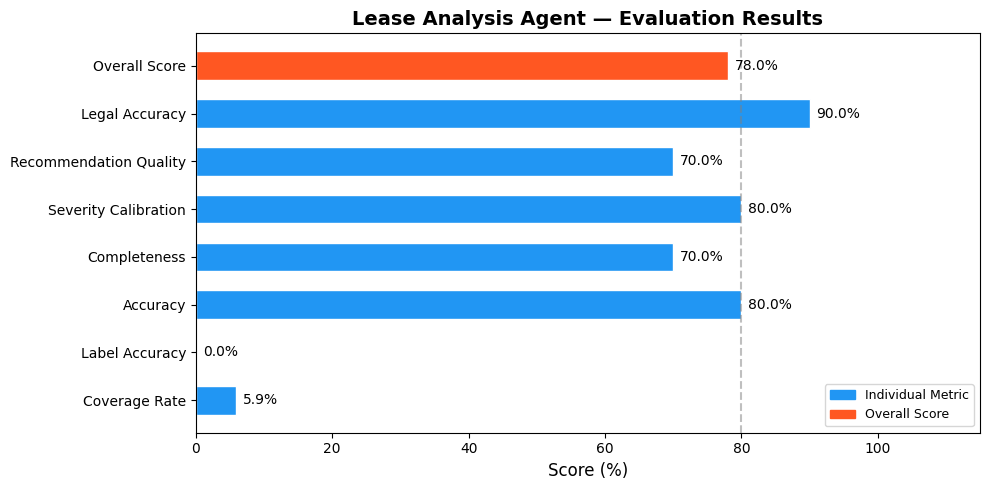

Chart saved to evaluation_results.png


In [6]:
# ── Assemble metrics dict ─────────────────────────────────────────────────
scores = judge_results.get("scores", {})

metrics = {
    "Coverage Rate": coverage_results.get("coverage_rate", 0.0),
    "Label Accuracy": coverage_results.get("label_accuracy", 0.0),
    "Accuracy": scores.get("accuracy", 0) / 10,
    "Completeness": scores.get("completeness", 0) / 10,
    "Severity Calibration": scores.get("severity_calibration", 0) / 10,
    "Recommendation Quality": scores.get("recommendation_quality", 0) / 10,
    "Legal Accuracy": scores.get("legal_accuracy", 0) / 10,
    "Overall Score": judge_results.get("overall_score", 0) / 10,
}

# ── Print summary table ───────────────────────────────────────────────────
print("=" * 55)
print(" LEASE ANALYSIS EVALUATION RESULTS")
print("=" * 55)
for name, value in metrics.items():
    bar = "█" * int(value * 20)
    print(f"  {name:<30}  {value:5.1%}  {bar}")
print("=" * 55)

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

metric_names = list(metrics.keys())
metric_values = [v * 100 for v in metrics.values()]

# Color bars: overall score highlighted
colors = ["#2196F3" if name != "Overall Score" else "#FF5722" for name in metric_names]

bars = ax.barh(metric_names, metric_values, color=colors, edgecolor="white", height=0.6)

# Value labels
for bar, val in zip(bars, metric_values):
    ax.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%", va="center", ha="left", fontsize=10
    )

ax.set_xlim(0, 115)
ax.set_xlabel("Score (%)", fontsize=12)
ax.set_title("Lease Analysis Agent — Evaluation Results", fontsize=14, fontweight="bold")
ax.axvline(x=80, color="gray", linestyle="--", alpha=0.5, label="80% threshold")
ax.legend(fontsize=9)

blue_patch  = mpatches.Patch(color="#2196F3", label="Individual Metric")
red_patch   = mpatches.Patch(color="#FF5722", label="Overall Score")
ax.legend(handles=[blue_patch, red_patch], fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to evaluation_results.png")

## Cell 7: Coverage Detail Table

In [7]:
# Detailed per-clause coverage table
match_rows = []
for m in coverage_results.get("matches", []):
    match_rows.append({
        "Ground Truth Clause": m.get("ground_truth_name", m.get("ground_truth_category", "")),
        "Found?": "✓" if m.get("found") else "✗",
        "Match Quality": m.get("match_quality", "—"),
        "Agent Finding": m.get("agent_finding_name", "—") or "—",
        "Label Match": m.get("label_match", "—"),
        "Severity Match": m.get("severity_match", "—"),
    })

if match_rows:
    df_coverage = pd.DataFrame(match_rows)
    pd.set_option("display.max_colwidth", 45)
    pd.set_option("display.max_rows", 30)
    print("Coverage Detail:")
    print(df_coverage.to_string(index=False))
    
    # Summary counts
    found_n    = (df_coverage["Found?"] == "✓").sum()
    correct_n  = (df_coverage["Label Match"] == "correct").sum()
    total_n    = len(df_coverage)
    print(f"\nFound: {found_n}/{total_n} | Correctly labeled: {correct_n}/{found_n}")
else:
    print("No match data available.")

Coverage Detail:
                    Ground Truth Clause Found? Match Quality                                                                       Agent Finding    Label Match Severity Match
          Waiver of Habitability Rights      ✗     not_found                                                                                   — not_applicable  not_available
      Eviction Without Judicial Process      ✗     not_found                                                                                   — not_applicable  not_available
          Acceleration of Rent Payments      ✗     not_found                                                                                   — not_applicable  not_available
   Tenant Pays Landlord's Attorney Fees      ✗     not_found                                                                                   — not_applicable  not_available
          Confession of Judgment Clause      ✗     not_found                                                

## Cell 8: Generate Evaluation Report

In [8]:
def fmt_pct(v):
    """Format a 0-1 float as a percentage string."""
    return f"{v:.1%}" if v is not None else "N/A"

# ── Coverage table (markdown) ─────────────────────────────────────────────
coverage_md_rows = []
for m in coverage_results.get("matches", []):
    found_icon = "✓" if m.get("found") else "✗"
    coverage_md_rows.append(
        f"| {m.get('ground_truth_name', m.get('ground_truth_category',''))} "
        f"| {found_icon} | {m.get('match_quality','—')} "
        f"| {m.get('agent_finding_name','—') or '—'} "
        f"| {m.get('label_match','—')} "
        f"| {m.get('severity_match','—')} "
        f"| {m.get('notes','—')} |"
    )
coverage_table = "\n".join(coverage_md_rows)

# ── Bullet lists ──────────────────────────────────────────────────────────
def to_bullets(items):
    return "\n".join(f"- {item}" for item in items) if items else "- (none identified)"

strengths_md  = to_bullets(judge_results.get("strengths", []))
weaknesses_md = to_bullets(judge_results.get("weaknesses", []))
missed_md     = to_bullets(judge_results.get("missed_issues", []))
fp_md         = to_bullets(judge_results.get("false_positives", []))

# ── Build report ──────────────────────────────────────────────────────────
report = f"""# Lease Analysis Agent — Evaluation Report

**Date:** {date.today()}  
**Agent output evaluated:** `clause_findings.csv` + `improvement_decision_report.md`  
**Ground truth source:** `ground_truth/ground_truth.json` ({len(gt_clauses)} clause types)

---

## Executive Summary

{judge_results.get('summary', 'N/A')}

---

## Evaluation Metrics

| Metric | Score | Method |
|--------|-------|--------|
| Coverage Rate | {fmt_pct(metrics['Coverage Rate'])} | LLM matching |
| Label Accuracy | {fmt_pct(metrics['Label Accuracy'])} | LLM matching |
| Accuracy | {fmt_pct(metrics['Accuracy'])} | LLM-as-judge |
| Completeness | {fmt_pct(metrics['Completeness'])} | LLM-as-judge |
| Severity Calibration | {fmt_pct(metrics['Severity Calibration'])} | LLM-as-judge |
| Recommendation Quality | {fmt_pct(metrics['Recommendation Quality'])} | LLM-as-judge |
| Legal Accuracy | {fmt_pct(metrics['Legal Accuracy'])} | LLM-as-judge |
| **Overall Score** | **{fmt_pct(metrics['Overall Score'])}** | Weighted avg |

*See `evaluation_results.png` for a visual summary.*

---

## Strengths

{strengths_md}

## Weaknesses

{weaknesses_md}

## Missed Issues

Issues present in the ground truth that the agent did not identify:

{missed_md}

## False Positives

Issues the agent flagged that were not genuinely problematic:

{fp_md}

---

## Coverage Detail

| Ground Truth Clause | Found? | Match Quality | Agent Finding | Label Match | Severity Match | Notes |
|---------------------|--------|--------------|---------------|-------------|----------------|-------|
{coverage_table}

---

## Methodology Notes

### Ground Truth Construction
The ground truth was built using two approaches:
1. **Reference PDFs**: Text was extracted from `rag_data/info/` documents ("10 Deadly Sins of a Lease", 
   "How to Identify and Fix Illegal Lease Clauses") using `pypdf`.
2. **Web scraping**: Public tenant-rights pages from NOLO, HUD, and the Illinois Attorney General were
   scraped using `requests` + `BeautifulSoup4`.
3. **LLM synthesis**: `gpt-4o-mini` was used to synthesize both sources into a structured JSON list of 
   clause types with expected labels, severity ranges, and key indicators.

### Evaluation Approach
Exact string matching is not suitable for legal text analysis (paraphrasing, different clause names, etc.).
Instead, two LLM-based evaluation methods were used:

1. **LLM Coverage Matching** (`gpt-4o-mini`): Matched each ground truth clause type to the agent's 
   findings, assessing whether each issue was identified and correctly labeled.
2. **LLM-as-Judge** (`gpt-4o`): Scored the analysis quality on five dimensions (Accuracy, Completeness, 
   Severity Calibration, Recommendation Quality, Legal Accuracy) on a 0-10 scale.

### Limitations
- LLM-based evaluation is itself subject to model bias and limitations.
- Ground truth reflects the reference documents used; other authoritative sources may yield different entries.
- Evaluation was performed on a single lease agreement (Chicago Bed Bug Addendum). Results may vary 
  across different lease types and jurisdictions.

---
*Generated by `02_evaluate_output.ipynb`*
"""

with open(REPORT_OUTPUT_PATH, "w", encoding="utf-8") as f:
    f.write(report)

print(f"Evaluation report saved to: {REPORT_OUTPUT_PATH.resolve()}")
print(f"Report length: {len(report):,} characters")

Evaluation report saved to: C:\Users\fblel\OneDrive\Desktop\Courses\Winter 2026\AI Financial Info\Files\busn30135_labs\aiforfinancialinformation\evaluation\evaluation_report.md
Report length: 5,949 characters
